# 课程内插图的代码

In [1]:
# Required packages for this notebook: torch, matplotlib, numpy, torchdiffeq
# If needed, install them with: pip install torch matplotlib numpy torchdiffeq

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp


plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

# 配置常见中文字体，避免图标题和图例乱码
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Heiti SC", "STHeiti", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

模拟系统：
\begin{align*}
    \left[
        \begin{array}{c}
            \dot x_1 \\ \dot x_2
        \end{array}
    \right]
    =
    \left[
        \begin{array}{c}
            \mu x_1 - x_2 - x_1^3 \\
            x_1 + \mu x_2
        \end{array}
    \right]
    &&
    \text{$\mu$ 是系统的参数}
\end{align*}

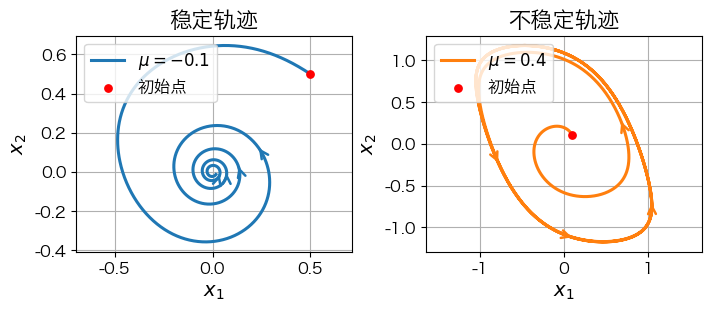

In [10]:

%matplotlib inline
# 模拟上述二阶非线性系统
# \dot{x}_1 = \mu x_1 - x_2 - x_1^3
# \dot{x}_2 = x_1 + \mu x_2

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


def dynamics(t, y, mu):
    x1, x2 = y
    return [
        mu * x1 - x2 - x1**3,
        x1 + mu * x2,
    ]


def simulate(mu, y0, t_end=50, n_points=2000):
    sol = solve_ivp(
        fun=lambda t, y: dynamics(t, y, mu),
        t_span=(0, t_end),
        y0=y0,
        t_eval=np.linspace(0, t_end, n_points),
        dense_output=True,
        rtol=1e-8,
        atol=1e-10,
    )
    return sol.t, sol.y


def add_trajectory_arrows(ax, x, y, n_arrows=4, color='C0'):
    arrow_positions = np.linspace(0, len(x) - 2, n_arrows + 2, dtype=int)[1:-1]
    for idx in arrow_positions:
        dx = x[idx + 1] - x[idx]
        dy = y[idx + 1] - y[idx]
        ax.annotate(
            '',
            xy=(x[idx] + dx, y[idx] + dy),
            xytext=(x[idx], y[idx]),
            arrowprops=dict(arrowstyle='->', color=color, lw=1.8, shrinkA=0, shrinkB=0),
        )


# 设定初值
y0 = [0.5, 0.5]

# 稳定情形
mu_stable = -0.1
_, state_stable = simulate(mu_stable, y0, t_end=30)

# 不稳定情形
mu_unstable = 0.4
y0 = [0.1, 0.1]
_, state_unstable = simulate(mu_unstable, y0, t_end=30)

# 并排绘制两张相平面轨迹图，便于放入 PDF
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

line0, = axes[0].plot(state_stable[0], state_stable[1], color='C0', lw=2.2, label=rf'$\mu={mu_stable}$')
start0 = axes[0].scatter(state_stable[0, 0], state_stable[1, 0], color='r', s=28, label='初始点', zorder=3)
add_trajectory_arrows(axes[0], state_stable[0], state_stable[1], n_arrows=4, color='C0')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_title('稳定轨迹')
axes[0].grid(True)
axes[0].axis('equal')
axes[0].legend(handles=[line0, start0], loc='upper left', frameon=True)

line1, = axes[1].plot(state_unstable[0], state_unstable[1], color='C1', lw=2.2, label=rf'$\mu={mu_unstable}$')
start1 = axes[1].scatter(state_unstable[0, 0], state_unstable[1, 0], color='r', s=28, label='初始点', zorder=3)
add_trajectory_arrows(axes[1], state_unstable[0], state_unstable[1], n_arrows=4, color='C1')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('不稳定轨迹')
axes[1].grid(True)
axes[1].axis('equal')
axes[1].legend(handles=[line1, start1], loc='upper left', frameon=True)

plt.show()


# 

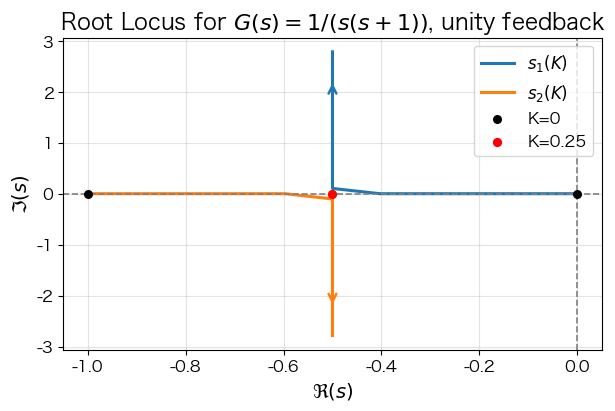

In [12]:
# 另一个系统示例：单位负反馈 + 比例控制
# 开环对象: G(s)=1/(s(s+1))
# 闭环特征方程: s^2 + s + K = 0
# 根轨迹即该二次方程的两根随 K>=0 的轨迹

import numpy as np
import matplotlib.pyplot as plt

K_values = np.linspace(0, 8, 400)

def closed_loop_roots(K):
    # s^2 + s + K = 0
    disc = 1 - 4 * K
    r1 = (-1 + np.sqrt(disc + 0j)) / 2
    r2 = (-1 - np.sqrt(disc + 0j)) / 2
    return r1, r2

roots1 = np.zeros_like(K_values, dtype=complex)
roots2 = np.zeros_like(K_values, dtype=complex)
for i, K in enumerate(K_values):
    r1, r2 = closed_loop_roots(K)
    roots1[i] = r1
    roots2[i] = r2

fig3, ax3 = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax3.plot(roots1.real, roots1.imag, color='C0', lw=2.2, label=r'$s_1(K)$')
ax3.plot(roots2.real, roots2.imag, color='C1', lw=2.2, label=r'$s_2(K)$')

# 标记起点 K=0: 极点在 0 和 -1
ax3.scatter([0, -1], [0, 0], color='k', s=30, zorder=3, label='K=0')

# 标记分离点 K=0.25: 双重极点在 -0.5
ax3.scatter([-0.5], [0], color='red', s=32, zorder=3, label='K=0.25')

# 用箭头表示 K 增大方向
idx_a, idx_b = 140, 260
ax3.annotate('', xy=(roots1.real[idx_b], roots1.imag[idx_b]), xytext=(roots1.real[idx_a], roots1.imag[idx_a]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C0'))
ax3.annotate('', xy=(roots2.real[idx_b], roots2.imag[idx_b]), xytext=(roots2.real[idx_a], roots2.imag[idx_a]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C1'))

ax3.axhline(0, color='gray', lw=1.2, ls='--')
ax3.axvline(0, color='gray', lw=1.2, ls='--')
ax3.set_xlabel(r'$\Re(s)$')
ax3.set_ylabel(r'$\Im(s)$')
ax3.set_title(r'Root Locus for $G(s)=1/(s(s+1))$, unity feedback')
ax3.grid(True, alpha=0.35)
ax3.legend(loc='upper right', frameon=True)

plt.show()

## 从 ODE 到 Root Locus 的示例
考虑带参数的线性 ODE 系统：
\begin{align*}
\dot{x}_1 &= x_2,\\
\dot{x}_2 &= -Kx_1 - x_2,\qquad K\ge 0
\end{align*}
写成矩阵形式 $\dot{x}=A(K)x$，其中
\[
A(K)=\begin{bmatrix}0&1\\-K&-1\end{bmatrix}.
\]
其特征方程为
\[
\det(\lambda I-A)=\lambda^2+\lambda+K=0.
\]
因此根轨迹就是该二次方程两根随 $K$ 变化的轨迹。

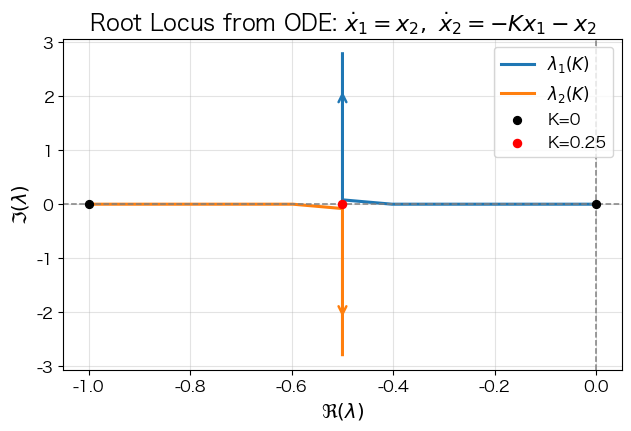

In [14]:
# 根据 ODE: xdot = A(K)x, A(K) = [[0,1],[-K,-1]]
import numpy as np
import matplotlib.pyplot as plt

K_vals = np.linspace(0, 8, 500)
r1_vals = np.zeros_like(K_vals, dtype=complex)
r2_vals = np.zeros_like(K_vals, dtype=complex)

for j, K in enumerate(K_vals):
    # lambda^2 + lambda + K = 0
    disc = 1 - 4 * K
    r1_vals[j] = (-1 + np.sqrt(disc + 0j)) / 2
    r2_vals[j] = (-1 - np.sqrt(disc + 0j)) / 2

fig4, ax4 = plt.subplots(figsize=(6.2, 4.2), constrained_layout=True)
ax4.plot(r1_vals.real, r1_vals.imag, lw=2.2, color='C0', label=r'$\lambda_1(K)$')
ax4.plot(r2_vals.real, r2_vals.imag, lw=2.2, color='C1', label=r'$\lambda_2(K)$')

# 关键点: K=0 与 K=0.25
ax4.scatter([0, -1], [0, 0], color='k', s=32, zorder=3, label='K=0')
ax4.scatter([-0.5], [0], color='red', s=34, zorder=3, label='K=0.25')

# K 增大方向
a, b = 120, 300
ax4.annotate('', xy=(r1_vals.real[b], r1_vals.imag[b]), xytext=(r1_vals.real[a], r1_vals.imag[a]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C0'))
ax4.annotate('', xy=(r2_vals.real[b], r2_vals.imag[b]), xytext=(r2_vals.real[a], r2_vals.imag[a]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C1'))

ax4.axhline(0, color='gray', ls='--', lw=1.1)
ax4.axvline(0, color='gray', ls='--', lw=1.1)
ax4.set_xlabel(r'$\Re(\lambda)$')
ax4.set_ylabel(r'$\Im(\lambda)$')
ax4.set_title('Root Locus from ODE: $\dot{x}_1=x_2,\ \dot{x}_2=-Kx_1-x_2$')
ax4.grid(True, alpha=0.35)
ax4.legend(loc='upper right', frameon=True)

plt.show()

## 另一个系统
系统：
\begin{align*}
\dot x &= \mu_1 x-\mu_2 y-x(x^2+y^2),\\
\dot y &= \mu_2 x+\mu_1 y-y(x^2+y^2).
\end{align*}
在平衡点 $(0,0)$ 处线性化：
\[
J(0,0)=\begin{bmatrix}\mu_1 & -\mu_2\\ \mu_2 & \mu_1\end{bmatrix},
\quad \lambda_{1,2}=\mu_1\pm i\mu_2.
\]
下面固定 $\mu_2=1$，让 $\mu_1$ 变化来画 root locus。

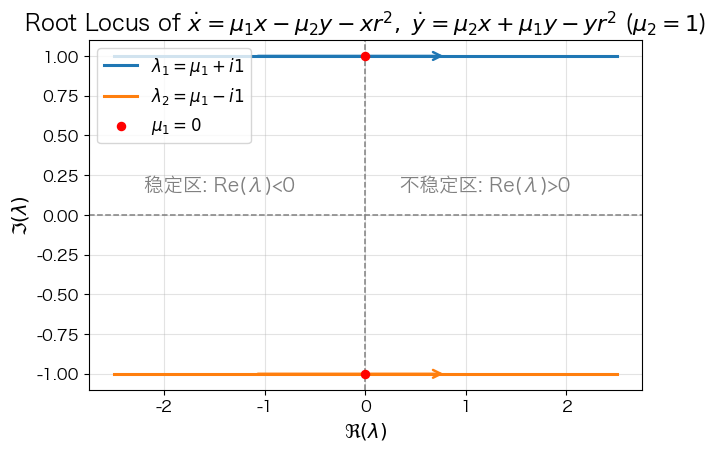

In [17]:
# 固定 mu2，扫描 mu1，绘制 lambda = mu1 ± i*mu2
import numpy as np
import matplotlib.pyplot as plt

mu2_fixed = 1.0
mu1_vals = np.linspace(-2.5, 2.5, 500)
lam_plus = mu1_vals + 1j * mu2_fixed
lam_minus = mu1_vals - 1j * mu2_fixed

fig5, ax5 = plt.subplots(figsize=(6.4, 4.4), constrained_layout=True)
ax5.plot(lam_plus.real, lam_plus.imag, lw=2.2, color='C0', label=rf'$\lambda_1=\mu_1+i{mu2_fixed:g}$')
ax5.plot(lam_minus.real, lam_minus.imag, lw=2.2, color='C1', label=rf'$\lambda_2=\mu_1-i{mu2_fixed:g}$')

# mu1 增大方向
m, n = 140, 330
ax5.annotate('', xy=(lam_plus.real[n], lam_plus.imag[n]), xytext=(lam_plus.real[m], lam_plus.imag[m]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C0'))
ax5.annotate('', xy=(lam_minus.real[n], lam_minus.imag[n]), xytext=(lam_minus.real[m], lam_minus.imag[m]),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='C1'))

# 临界点 mu1=0
ax5.scatter([0, 0], [mu2_fixed, -mu2_fixed], color='red', s=34, zorder=3, label=r'$\mu_1=0$')

ax5.axvline(0, color='gray', lw=1.1, ls='--')
ax5.axhline(0, color='gray', lw=1.1, ls='--')
ax5.text(-2.2, 0.15, '稳定区: Re(λ)<0', color='gray')
ax5.text(0.35, 0.15, '不稳定区: Re(λ)>0', color='gray')

ax5.set_xlabel(r'$\Re(\lambda)$')
ax5.set_ylabel(r'$\Im(\lambda)$')
ax5.set_title(r'Root Locus of $\dot x=\mu_1x-\mu_2y-xr^2,\ \dot y=\mu_2x+\mu_1y-yr^2$ ($\mu_2=1$)')
ax5.grid(True, alpha=0.35)
ax5.legend(loc='upper left', frameon=True)

plt.show()